# 05 - Sampling robustness of the pathway footprints  (Stage 5)

**Purpose.** The pathway maps in notebook 04 draw a fixed random sample of
`C.PLOT_SAMPLE_PER_LABEL` trajectories per label (seed `C.RANDOM_STATE`). This
notebook checks how much that picture depends on *which* particles were drawn:
we resample under several seeds and compare the per-label occupancy footprints.

**Important:** the k-means labels themselves are NOT re-computed here. Every
particle keeps the `cluster_label` / `cluster_group` assigned in stage 3, so this
tests *sampling* stability (does the drawn footprint change with the seed?), NOT
clustering stability (that would require refitting k-means -- a different test).
Because each label is sampled with thousands of trajectories x ~hundreds of obs,
the core footprint should be very stable; only the rare-excursion fringe moves.

**Input.** `data/labeled_trajectories.parquet` (stage 3) + the Zarr stores.
**Output.** Per-label agreement maps and a stability (IoU) table in `figures/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root: config.py, pipeline.py
import numpy as np
import pandas as pd
import config as C
import pipeline as P
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
from joblib import Parallel, delayed
from tqdm import tqdm
print("project root:", C.PROJECT_ROOT)
print("sampling days:", C.DAYS, "| plot sample/label:", C.PLOT_SAMPLE_PER_LABEL)

project root: /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_30_180_stdZ_w
sampling days: [30, 50, 100, 150, 180] | plot sample/label: 5000


In [2]:
BEST_K    = 50                 # must match notebooks 03 / 04
LABEL_COL = "cluster_group"    # "cluster_group" (merged) or "cluster_label" (raw)
SEEDS     = [42, 1, 7, 13, 99] # the random seeds to compare (>=2)
N_PLOT    = C.PLOT_SAMPLE_PER_LABEL   # trajectories per label per seed
N_IO_THREADS = 16
LAT_THRESH   = 10.0            # (kept for parity; unused here)
print(f"{len(SEEDS)} seeds x <= {N_PLOT:,} trajectories/label")

5 seeds x <= 5,000 trajectories/label


In [3]:
# --- per-seed samples, then read the UNION of needed trajectories ONCE -------
# Each seed draws its own <=N_PLOT/label sample. We read every trajectory that
# ANY seed needs a single time (parallel), cache lon/lat, and build each seed's
# footprints from RAM -> the Zarr is read once, not len(SEEDS) times.
lab = pd.read_parquet(C.LABELED_FILE)
labelled = lab[lab[LABEL_COL] >= 0].copy()
n_lab = int(labelled[LABEL_COL].max()) + 1
stores = C.list_stores()

picks = {}
for s in SEEDS:
    p = (labelled.groupby(LABEL_COL, group_keys=False)
         .apply(lambda d: d.sample(min(N_PLOT, len(d)), random_state=s)))
    picks[s] = p[["trajectory_id", LABEL_COL]].rename(columns={LABEL_COL: "lab"}).copy()

need = pd.concat(picks.values()).drop_duplicates("trajectory_id")[["trajectory_id"]].copy()
need["store_index"] = need.trajectory_id // C.TRAJ_PER_STORE
need["local"]       = need.trajectory_id %  C.TRAJ_PER_STORE
print(f"union of all seeds: {len(need):,} unique trajectories "
      f"(vs {len(SEEDS)*n_lab*N_PLOT:,} seed-slots)")

def _read_store(si, grp):
    ds  = xr.open_zarr(stores[si])
    loc = grp.local.to_numpy()
    lon = ds.lon.values[loc].astype("float32")
    lat = ds.lat.values[loc].astype("float32")
    return grp.trajectory_id.to_numpy(), lon, lat

groups  = list(need.groupby("store_index"))
results = Parallel(n_jobs=N_IO_THREADS, backend="threading")(
    delayed(_read_store)(si, grp) for si, grp in tqdm(groups))
paths = {}
for tids, lon, lat in results:
    for k, tid in enumerate(tids):
        paths[int(tid)] = (lon[k], lat[k])
print(f"cached {len(paths):,} trajectories")

/tmp/ipykernel_898901/4244428633.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(min(N_PLOT, len(d)), random_state=s)))
/tmp/ipykernel_898901/4244428633.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(min(N_PLOT, len(d)), random_state=s)))
/tmp/ipykernel_898901/4244428633.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This b

union of all seeds: 172,377 unique trajectories (vs 175,000 seed-slots)


100%|██████████| 1616/1616 [01:11<00:00, 22.68it/s]


cached 172,377 trajectories


In [4]:
# --- boolean occupancy footprint per (seed, label) --------------------------
# Same grid / obs-0 drop as notebook 04. occ[seed] has shape (n_lab, nlat, nlon).
lon_bins = np.linspace(C.DOMAIN["lon_min"], C.DOMAIN["lon_max"], 80)
lat_bins = np.linspace(C.DOMAIN["lat_min"], C.DOMAIN["lat_max"], 30)
nlat, nlon = lat_bins.size - 1, lon_bins.size - 1

def occupancy(pick_df):
    xs = {c: [] for c in range(n_lab)}; ys = {c: [] for c in range(n_lab)}
    for tid, l in zip(pick_df.trajectory_id.to_numpy(), pick_df.lab.to_numpy()):
        lon, lat = paths[int(tid)]
        xs[l].append(lon[1:]); ys[l].append(lat[1:])          # drop obs 0
    occ = np.zeros((n_lab, nlat, nlon), dtype=bool)
    for c in range(n_lab):
        x = np.concatenate(xs[c]); y = np.concatenate(ys[c])
        m = ~(np.isnan(x) | np.isnan(y))
        h, _, _ = np.histogram2d(x[m], y[m], bins=[lon_bins, lat_bins])
        occ[c] = h.T > 0
    return occ

occ = {s: occupancy(picks[s]) for s in SEEDS}
agree = np.sum([occ[s] for s in SEEDS], axis=0)   # (n_lab, nlat, nlon) counts 0..len(SEEDS)
print("agreement array:", agree.shape, "| values 0..", len(SEEDS))

agreement array: (7, 29, 79) | values 0.. 5


## Agreement maps

For each label, colour every grid cell by **how many of the seeds** put a
particle there. Cells hit by *all* seeds are the robust core of the pathway;
cells hit by only one seed are sampling-dependent fringe. A footprint that
"holds its shape" is mostly dark (all-seed) with a thin light rim.

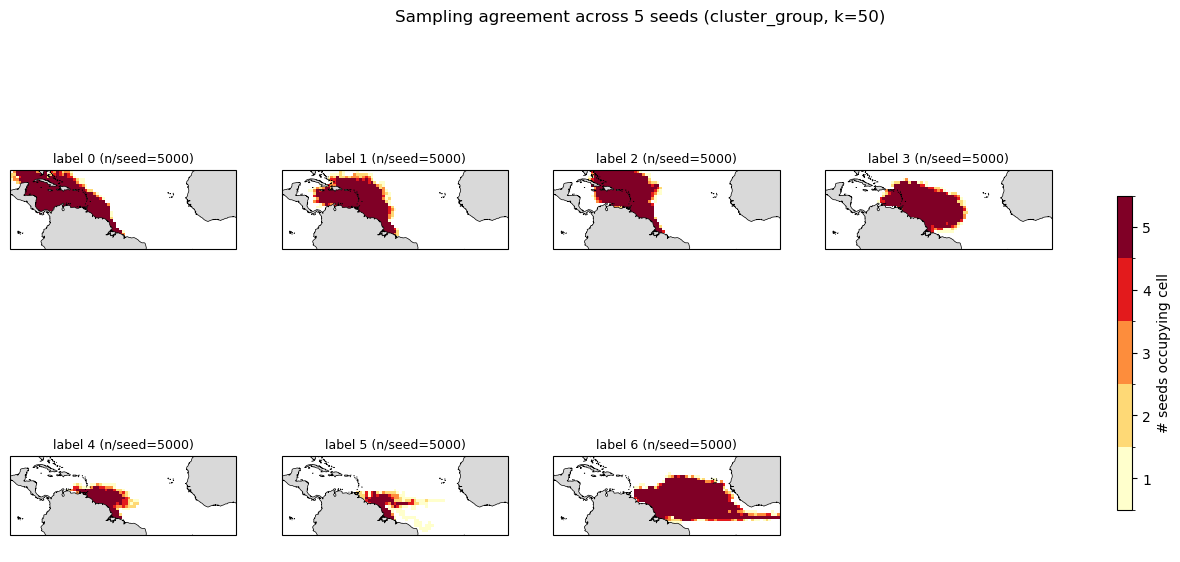

In [5]:
M = len(SEEDS)
cmap_a = plt.get_cmap("YlOrRd", M)
norm_a = BoundaryNorm(np.arange(0.5, M + 1.5), M)
ncol = min(n_lab, 4); nrow = int(np.ceil(n_lab / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.4*nrow),
                         subplot_kw={"projection": ccrs.PlateCarree()}, squeeze=False)
axflat = axes.ravel()
for c in range(n_lab):
    ax = axflat[c]
    ax.set_extent([C.DOMAIN["lon_min"], C.DOMAIN["lon_max"],
                   C.DOMAIN["lat_min"], C.DOMAIN["lat_max"]], crs=ccrs.PlateCarree())
    a = np.where(agree[c] > 0, agree[c], np.nan)
    pcm = ax.pcolormesh(lon_bins, lat_bins, a, cmap=cmap_a, norm=norm_a,
                        transform=ccrs.PlateCarree(), zorder=1)
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2); ax.coastlines(lw=.5, zorder=3)
    ax.set_title(f"label {c} (n/seed={int((picks[SEEDS[0]].lab==c).sum())})", fontsize=9)
for k in range(n_lab, nrow*ncol):
    axflat[k].axis("off")
cb = fig.colorbar(pcm, ax=axes, shrink=.6, ticks=range(1, M+1), label="# seeds occupying cell")
fig.suptitle(f"Sampling agreement across {M} seeds ({LABEL_COL}, k={BEST_K})", y=1.0, fontsize=12)
fig.savefig(C.FIG_DIR / f"sampling_agreement_k{BEST_K}_{LABEL_COL}.png", dpi=130, bbox_inches="tight")
plt.show()

## Stability table (Jaccard / IoU)

Per label, the **core/union ratio** = cells hit by *all* seeds divided by cells
hit by *any* seed (1.0 = every seed agrees everywhere). **mean IoU** = average
Jaccard overlap over all seed pairs (1.0 = identical footprints). Both near 1
means the cluster's shape is robust to the sampling seed.

In [6]:
from itertools import combinations
rows = []
for c in range(n_lab):
    core  = int((agree[c] == M).sum())     # all seeds
    union = int((agree[c] >= 1).sum())     # any seed
    ious = []
    for a, b in combinations(SEEDS, 2):
        inter = np.logical_and(occ[a][c], occ[b][c]).sum()
        uni   = np.logical_or(occ[a][c], occ[b][c]).sum()
        ious.append(inter / uni if uni else np.nan)
    rows.append(dict(label=c,
                     cells_union=union,
                     core_over_union=round(core / union, 3) if union else np.nan,
                     mean_pairwise_IoU=round(float(np.nanmean(ious)), 3)))
stability = pd.DataFrame(rows)
stability.to_csv(C.DATA_DIR / f"sampling_stability_k{BEST_K}_{LABEL_COL}.csv", index=False)
print(stability.to_string(index=False))
print(f"\noverall mean IoU: {stability.mean_pairwise_IoU.mean():.3f} "
      f"(1.0 = footprints identical across seeds)")

 label  cells_union  core_over_union  mean_pairwise_IoU
     0          400            0.833              0.913
     1          372            0.715              0.844
     2          346            0.847              0.922
     3          378            0.794              0.897
     4          161            0.571              0.762
     5          173            0.301              0.562
     6          539            0.798              0.897

overall mean IoU: 0.828 (1.0 = footprints identical across seeds)
